In [1]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visits = pd.read_csv('visits_1k.csv')
registrations = pd.read_csv('regs_1k.csv')

In [3]:
visits.head()

,uuid,platform,user_agent,date
0,1de9ea66-70d3-4a1f-8735-df5ef7697fb9,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-03-01T13:29:22
1,f149f542-e935-4870-9734-6b4501eaf614,web,Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,2023-03-01T16:44:28
2,f149f542-e935-4870-9734-6b4501eaf614,web,Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,2023-03-06T06:12:36
3,08f0ebd4-950c-4dd9-8e97-b5bdf073eed1,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-03-01T20:16:37
4,08f0ebd4-950c-4dd9-8e97-b5bdf073eed1,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-03-05T17:42:47


In [4]:
registrations.head()

,date,user_id,email,platform,registration_type
0,2023-03-01T00:25:39,8838849,joseph95@example.org,web,google
1,2023-03-01T14:53:01,8741065,janetsuarez@example.net,web,yandex
2,2023-03-01T14:27:36,1866654,robert67@example.org,web,google
3,2023-03-01T02:42:34,1577584,elam@example.net,web,apple
4,2023-03-01T10:27:14,4765395,stephanie68@example.net,web,yandex


In [5]:
visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   uuid        1000 non-null   str  
 1   platform    1000 non-null   str  
 2   user_agent  1000 non-null   str  
 3   date        1000 non-null   str  
dtypes: str(4)
memory usage: 31.4 KB


In [6]:
registrations.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   date               1000 non-null   str  
 1   user_id            1000 non-null   int64
 2   email              1000 non-null   str  
 3   platform           1000 non-null   str  
 4   registration_type  1000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 39.2 KB


In [7]:
visits.describe(include='all')

,uuid,platform,user_agent,date
count,1000,1000,1000,1000
unique,519,3,28,996
top,251a0926-ece3-4d77-aa42-ab569fdf9fe2,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-03-01T08:01:45
freq,4,954,71,2


In [8]:
registrations.describe(include='all')

,date,user_id,email,platform,registration_type
count,1000,1.000000e+03,1000,1000,1000
unique,1000,NaN,997,3,4
top,2023-03-01T00:25:39,NaN,zanderson@example.org,android,email
freq,1,NaN,2,517,446
mean,NaN,4.488623e+06,NaN,NaN,NaN
std,NaN,2.620568e+06,NaN,NaN,NaN
min,NaN,2.236800e+04,NaN,NaN,NaN
25%,NaN,2.235489e+06,NaN,NaN,NaN
50%,NaN,4.473044e+06,NaN,NaN,NaN
75%,NaN,6.779707e+06,NaN,NaN,NaN


In [9]:
visits.isna().sum()

uuid          0
platform      0
user_agent    0
date          0
dtype: int64

In [10]:
registrations.isna().sum()

date                 0
user_id              0
email                0
platform             0
registration_type    0
dtype: int64

In [11]:
visits.duplicated().sum()

np.int64(0)

In [12]:
registrations.duplicated().sum()

np.int64(0)

In [13]:
# Запросы к API

In [14]:
base_url = 'https://data-charts-api.hexlet.app'

begin = '2023-03-01'
end = '2023-09-01'

In [15]:
visits_response = requests.get(
    f'{base_url}/visits',
    params={
        'begin': begin,
        'end': end
    }
)

visits_response.raise_for_status()

In [16]:
registrations_response = requests.get(
    f'{base_url}/registrations',
    params={
        'begin': begin,
        'end': end
    }
)

registrations_response.raise_for_status()

In [17]:
visits_api = pd.DataFrame(visits_response.json())
registrations_api = pd.DataFrame(registrations_response.json())

In [18]:
visits_api.head()

,visit_id,platform,user_agent,datetime
0,60db9b85-12b3-447a-b93d-be177181f732,web,Mozilla/5.0 (Windows NT 10.0; WOW64; Trident/7...,2023-04-05T15:03:40
1,9e73a9ba-0c42-4a4d-bf8a-bde5bbe655ed,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-05T10:59:38
2,9e73a9ba-0c42-4a4d-bf8a-bde5bbe655ed,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-03T14:53:40
3,16dea4d8-2fb7-4c6b-b953-dc2b9686daf5,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-05T03:12:36
4,166bc823-c133-41fa-913d-3dbc495b2770,web,Mozilla/5.0 (Windows NT 10.0; WOW64; Trident/7...,2023-04-05T11:48:56


In [19]:
registrations_api.head()

,datetime,user_id,email,platform,registration_type
0,2023-03-01T07:40:13,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ebyrd@example.org,web,google
1,2023-03-01T13:14:00,f007f97c-9d8b-48b5-af08-119bb8f6d9b6,knightgerald@example.org,web,email
2,2023-03-01T03:05:50,24ff46ae-32b3-4a74-8f27-7cf0b8f32f15,cherylthompson@example.com,web,apple
3,2023-03-01T00:04:47,3e9914e1-5d73-4c23-b25d-b59a3aeb2b60,halldavid@example.org,web,email
4,2023-03-01T18:31:52,27f875fc-f8ce-4aeb-8722-0ecb283d0760,denise86@example.net,web,google


In [20]:
visits_api.shape, registrations_api.shape

((263459, 4), (21836, 5))

In [21]:
visits_api.info()

<class 'pandas.DataFrame'>
RangeIndex: 263459 entries, 0 to 263458
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   visit_id    263459 non-null  str  
 1   platform    263459 non-null  str  
 2   user_agent  263459 non-null  str  
 3   datetime    263459 non-null  str  
dtypes: str(4)
memory usage: 8.0 MB


In [22]:
registrations_api.info()

<class 'pandas.DataFrame'>
RangeIndex: 21836 entries, 0 to 21835
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   datetime           21836 non-null  str  
 1   user_id            21836 non-null  str  
 2   email              21836 non-null  str  
 3   platform           21836 non-null  str  
 4   registration_type  21836 non-null  str  
dtypes: str(5)
memory usage: 853.1 KB


In [23]:
# Подготовка данных

In [24]:
visits_api['datetime'] = pd.to_datetime(visits_api['datetime'])
registrations_api['datetime'] = pd.to_datetime(registrations_api['datetime'])

In [25]:
# Исключение визитов ботов

In [26]:
visits_api = visits_api[
    ~visits_api['user_agent'].str.contains('bot', case=False, na=False)
]

In [27]:
# Выбор последнего визита пользователя

In [28]:
visits_api = visits_api.sort_values('datetime')

In [29]:
visits_api = visits_api.drop_duplicates(
    subset='visit_id',
    keep='last'
)

In [30]:
# Группировка данных

In [31]:
visits_api['date_group'] = visits_api['datetime'].dt.date
registrations_api['date_group'] = registrations_api['datetime'].dt.date

In [32]:
visits_grouped = (
    visits_api
    .groupby(['date_group', 'platform'])
    .size()
    .reset_index(name='visits')
)

In [33]:
registrations_grouped = (
    registrations_api
    .groupby(['date_group', 'platform'])
    .size()
    .reset_index(name='registrations')
)

In [34]:
# Расчет конверсии

In [35]:
conversion = visits_grouped.merge(
    registrations_grouped,
    on=['date_group', 'platform'],
    how='left'
)

In [36]:
conversion['registrations'] = (
    conversion['registrations']
    .fillna(0)
    .astype(int)
)

In [37]:
conversion['conversion'] = (
    conversion['registrations']
    / conversion['visits']
    * 100
)

In [38]:
# Сортировка по дате

In [39]:
conversion = conversion.sort_values(
    ['date_group', 'platform']
)

In [40]:
# Сохранение результата

In [41]:
conversion.to_json('conversion.json')

In [42]:
conversion.head()

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355


In [43]:
# Добавление рекламных кампаний

In [44]:
ads = pd.read_csv('ads.csv')

ads.head()

,date,utm_source,utm_medium,utm_campaign,cost
0,2023-03-01T10:54:41,google,cpc,advanced_algorithms_series,212
1,2023-03-02T10:32:35,google,cpc,advanced_algorithms_series,252
2,2023-03-03T19:21:40,google,cpc,advanced_algorithms_series,202
3,2023-03-04T17:52:04,google,cpc,advanced_algorithms_series,223
4,2023-03-05T05:35:13,google,cpc,advanced_algorithms_series,265


In [45]:
# Преобразование дат

In [46]:
ads['date'] = pd.to_datetime(ads['date'])
ads['date_group'] = ads['date'].dt.normalize()

conversion['date_group'] = pd.to_datetime(conversion['date_group'])

In [47]:
# Группировка конверсии по дате

In [48]:
conversion_by_date = (
    conversion
    .groupby('date_group', as_index=False)
    .agg(
        visits=('visits', 'sum'),
        registrations=('registrations', 'sum')
    )
)

In [49]:
# Группировка рекламных кампаний

In [50]:
ads_grouped = (
    ads
    .groupby(['date_group', 'utm_campaign'], as_index=False)
    .agg(cost=('cost', 'sum'))
)

In [51]:
# Объединение таблиц

In [52]:
ads_result = conversion_by_date.merge(
    ads_grouped,
    on='date_group',
    how='left'
)

In [53]:
# 

In [54]:
ads_result['cost'] = (
    ads_result['cost']
    .fillna(0)
    .astype(int)
)

ads_result['utm_campaign'] = (
    ads_result['utm_campaign']
    .fillna('none')
)

In [55]:
ads_result = (
    ads_result[
        [
            'date_group',
            'visits',
            'registrations',
            'cost',
            'utm_campaign'
        ]
    ]
    .sort_values('date_group')
    .reset_index(drop=True)
)

In [56]:
ads_result.head(20)

,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,376,87,212,advanced_algorithms_series
1,2023-03-02,613,106,252,advanced_algorithms_series
2,2023-03-03,683,107,202,advanced_algorithms_series
3,2023-03-04,647,159,223,advanced_algorithms_series
4,2023-03-05,707,115,265,advanced_algorithms_series
5,2023-03-06,1291,230,108,advanced_algorithms_series
6,2023-03-07,1382,124,165,advanced_algorithms_series
7,2023-03-08,1382,151,155,advanced_algorithms_series
8,2023-03-09,1064,209,124,advanced_algorithms_series
9,2023-03-10,812,112,276,advanced_algorithms_series


In [57]:
ads_result.to_json('ads.json')

/var/folders/lz/q7jcjsq90hl_y4cfqvws8l_00000gn/T/ipykernel_38058/2159908971.py:1: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  ads_result.to_json('ads.json')


In [58]:
import os
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("charts", exist_ok=True)

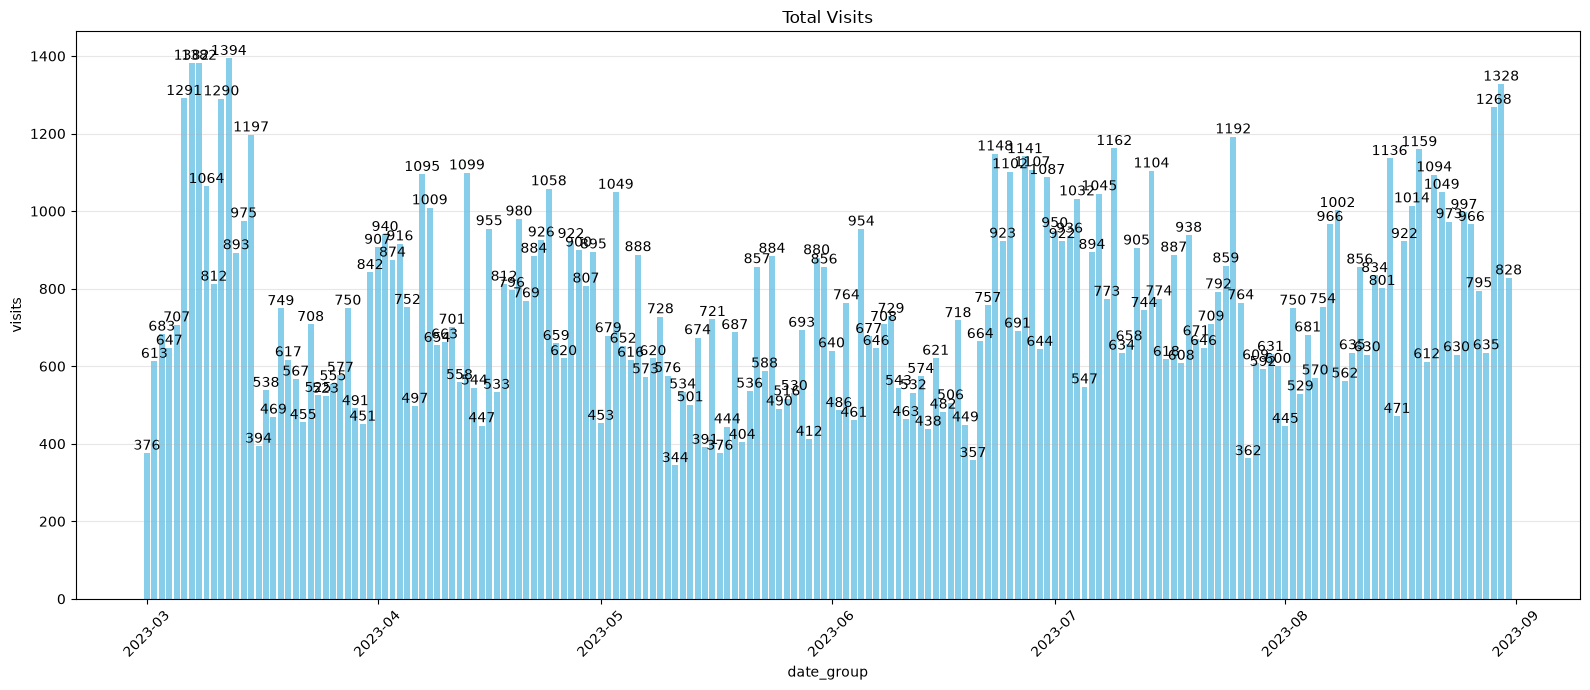

In [59]:
# Итоговые визиты

total_visits = (
    conversion
    .groupby('date_group', as_index=False)['visits']
    .sum()
)

plt.figure(figsize=(16, 7))

bars = plt.bar(
    total_visits['date_group'],
    total_visits['visits'],
    color='skyblue'
)

plt.title('Total Visits')
plt.xlabel('date_group')
plt.ylabel('visits')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig('./charts/total_visits.png')
plt.show()

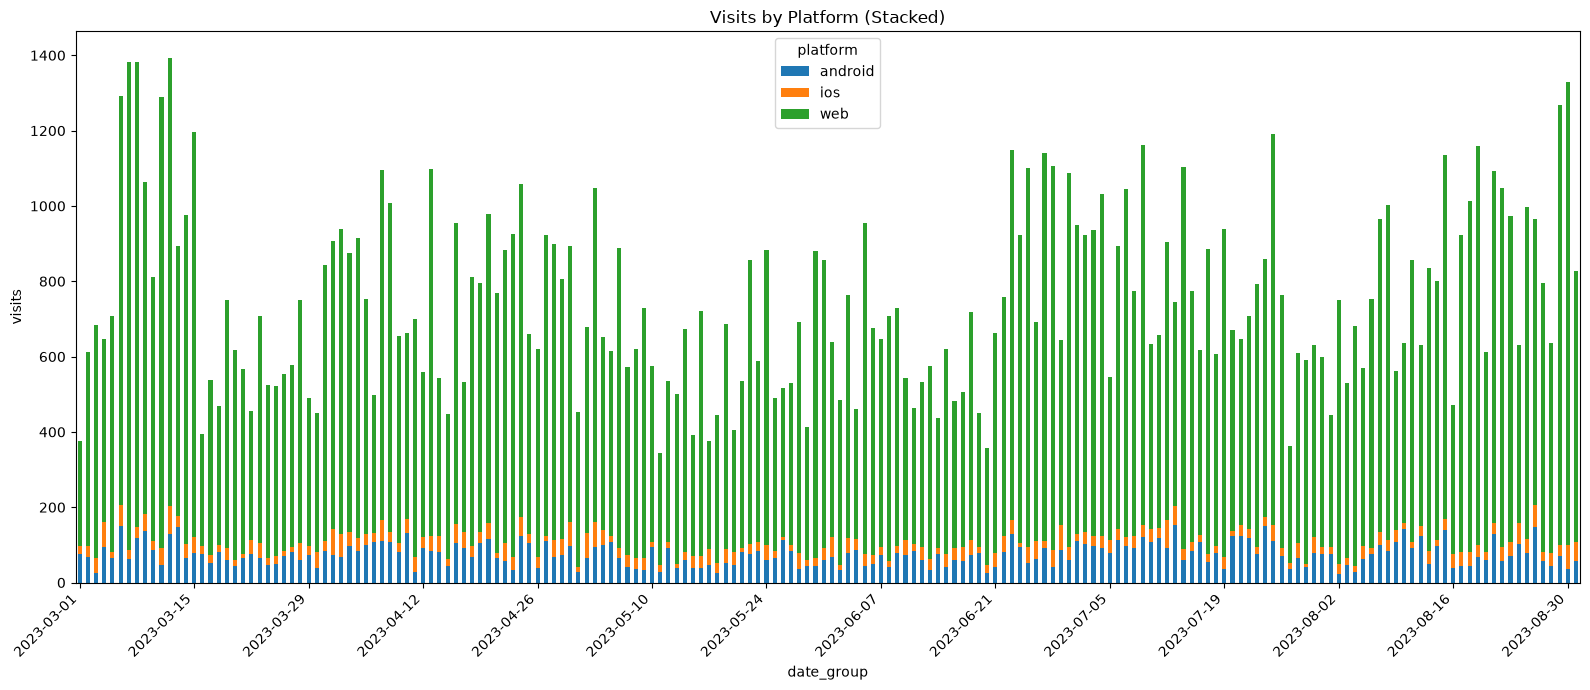

In [60]:
# Итоговые визиты с разбивкой по платформам

visits_by_platform = conversion.pivot(
    index='date_group',
    columns='platform',
    values='visits'
).reset_index()

visits_by_platform['date_group'] = (
    visits_by_platform['date_group']
    .dt.strftime('%Y-%m-%d')
)

visits_by_platform.plot(
    x='date_group',
    y=['android', 'ios', 'web'],
    kind='bar',
    stacked=True,
    figsize=(16, 7)
)

plt.title('Visits by Platform (Stacked)')
plt.xlabel('date_group')
plt.ylabel('visits')
plt.legend(title='platform')

ax = plt.gca()

step = 14
ticks = range(0, len(visits_by_platform), step)

ax.set_xticks(ticks)
ax.set_xticklabels(
    visits_by_platform['date_group'].iloc[::step],
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.savefig('./charts/visits_by_platform.png')
plt.show()

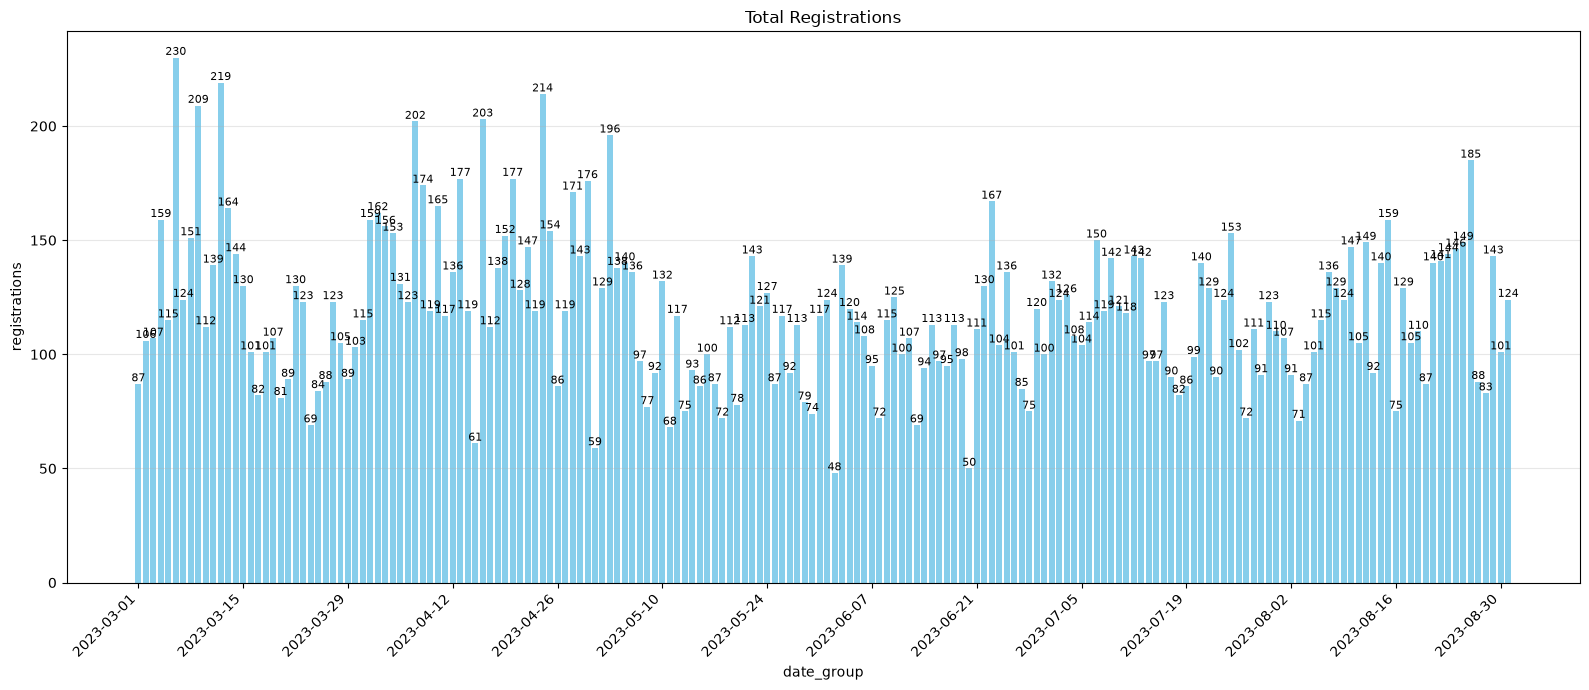

In [61]:
# Итоговые регистрации

total_registrations = (
    conversion
    .groupby('date_group', as_index=False)['registrations']
    .sum()
)

total_registrations['date_group'] = (
    total_registrations['date_group']
    .dt.strftime('%Y-%m-%d')
)

plt.figure(figsize=(16, 7))

bars = plt.bar(
    total_registrations['date_group'],
    total_registrations['registrations'],
    color='skyblue'
)

plt.title('Total Registrations')
plt.xlabel('date_group')
plt.ylabel('registrations')
plt.grid(axis='y', alpha=0.3)

ax = plt.gca()

step = 14
ticks = range(0, len(total_registrations), step)

ax.set_xticks(ticks)
ax.set_xticklabels(
    total_registrations['date_group'].iloc[::step],
    rotation=45,
    ha='right'
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.savefig('./charts/total_registrations.png')
plt.show()

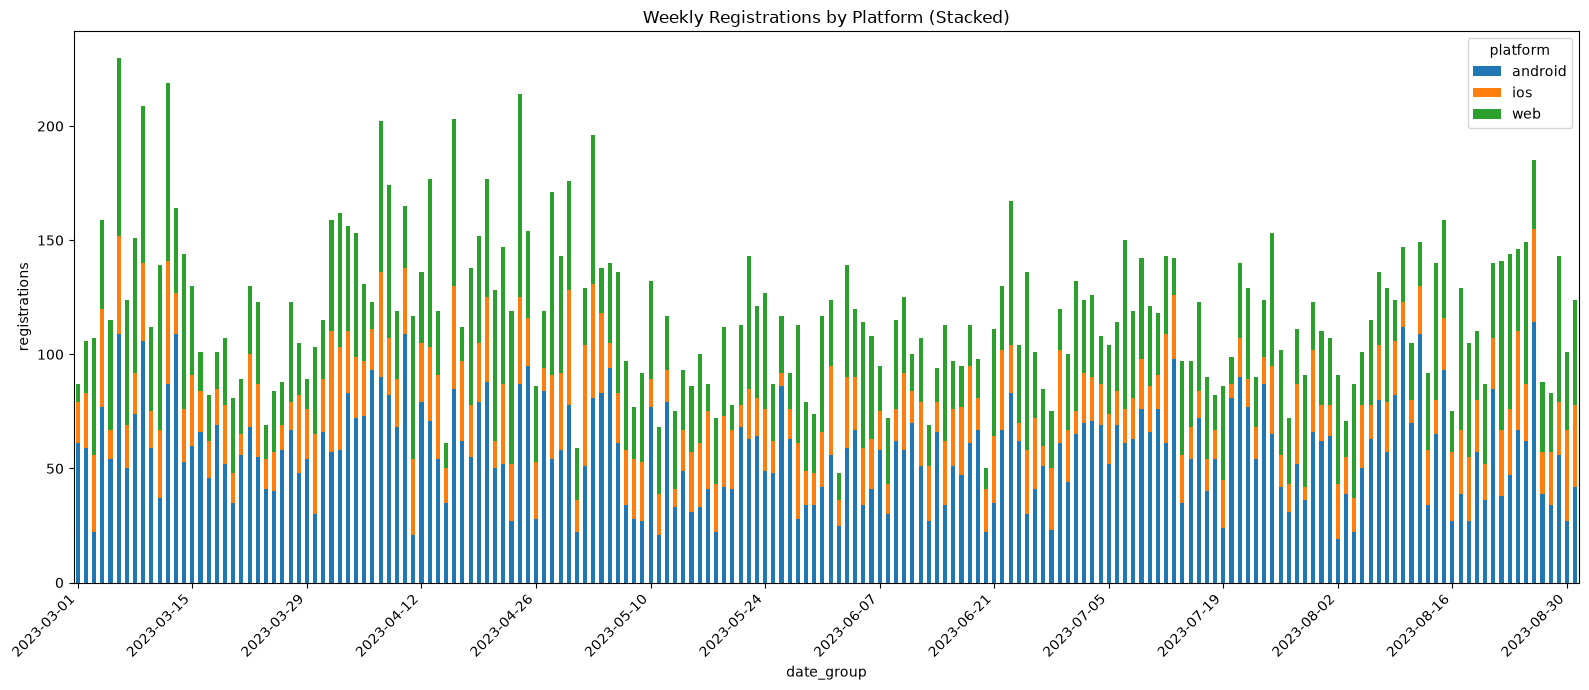

In [62]:
# Итоговые регистрации с разбивкой по платформам

registrations_by_platform = (
    conversion
    .pivot_table(
        index='date_group',
        columns='platform',
        values='registrations',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

registrations_by_platform['date_group'] = (
    registrations_by_platform['date_group']
    .dt.strftime('%Y-%m-%d')
)

registrations_by_platform.plot(
    x='date_group',
    y=['android', 'ios', 'web'],
    kind='bar',
    stacked=True,
    figsize=(16, 7)
)

plt.title('Weekly Registrations by Platform (Stacked)')
plt.xlabel('date_group')
plt.ylabel('registrations')
plt.legend(title='platform')

ax = plt.gca()

step = 14
ticks = range(0, len(registrations_by_platform), step)

ax.set_xticks(ticks)
ax.set_xticklabels(
    registrations_by_platform['date_group'].iloc[::step],
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.savefig('./charts/registrations_by_platform.png')
plt.show()

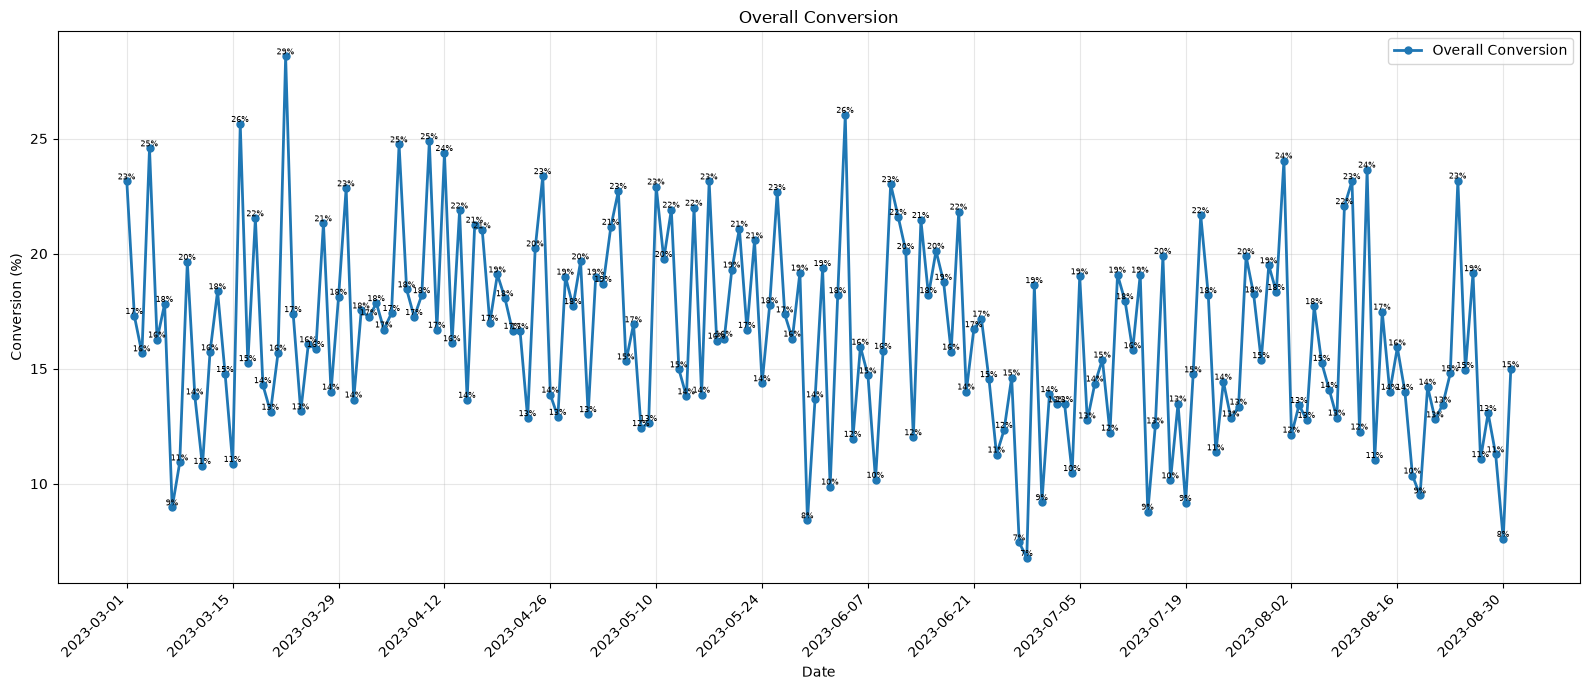

In [63]:
# Итоговая конверсия

overall_conversion = (
    conversion
    .groupby('date_group', as_index=False)
    .agg(
        visits=('visits', 'sum'),
        registrations=('registrations', 'sum')
    )
)

overall_conversion['conversion'] = (
    overall_conversion['registrations']
    / overall_conversion['visits']
    * 100
)

overall_conversion['date_group'] = (
    overall_conversion['date_group']
    .dt.strftime('%Y-%m-%d')
)

plt.figure(figsize=(16, 7))

plt.plot(
    overall_conversion['date_group'],
    overall_conversion['conversion'],
    marker='o',
    markersize=5,
    linewidth=2,
    label='Overall Conversion'
)

plt.title('Overall Conversion')
plt.xlabel('Date')
plt.ylabel('Conversion (%)')
plt.legend()
plt.grid(alpha=0.3)

ax = plt.gca()

step = 14
ticks = range(0, len(overall_conversion), step)

ax.set_xticks(ticks)
ax.set_xticklabels(
    overall_conversion['date_group'].iloc[::step],
    rotation=45,
    ha='right'
)

for x, y in zip(
    overall_conversion['date_group'],
    overall_conversion['conversion']
):
    plt.text(
        x,
        y,
        f'{y:.0f}%',
        ha='center',
        va='bottom',
        fontsize=6
    )

plt.tight_layout()
plt.savefig('./charts/overall_conversion.png')
plt.show()

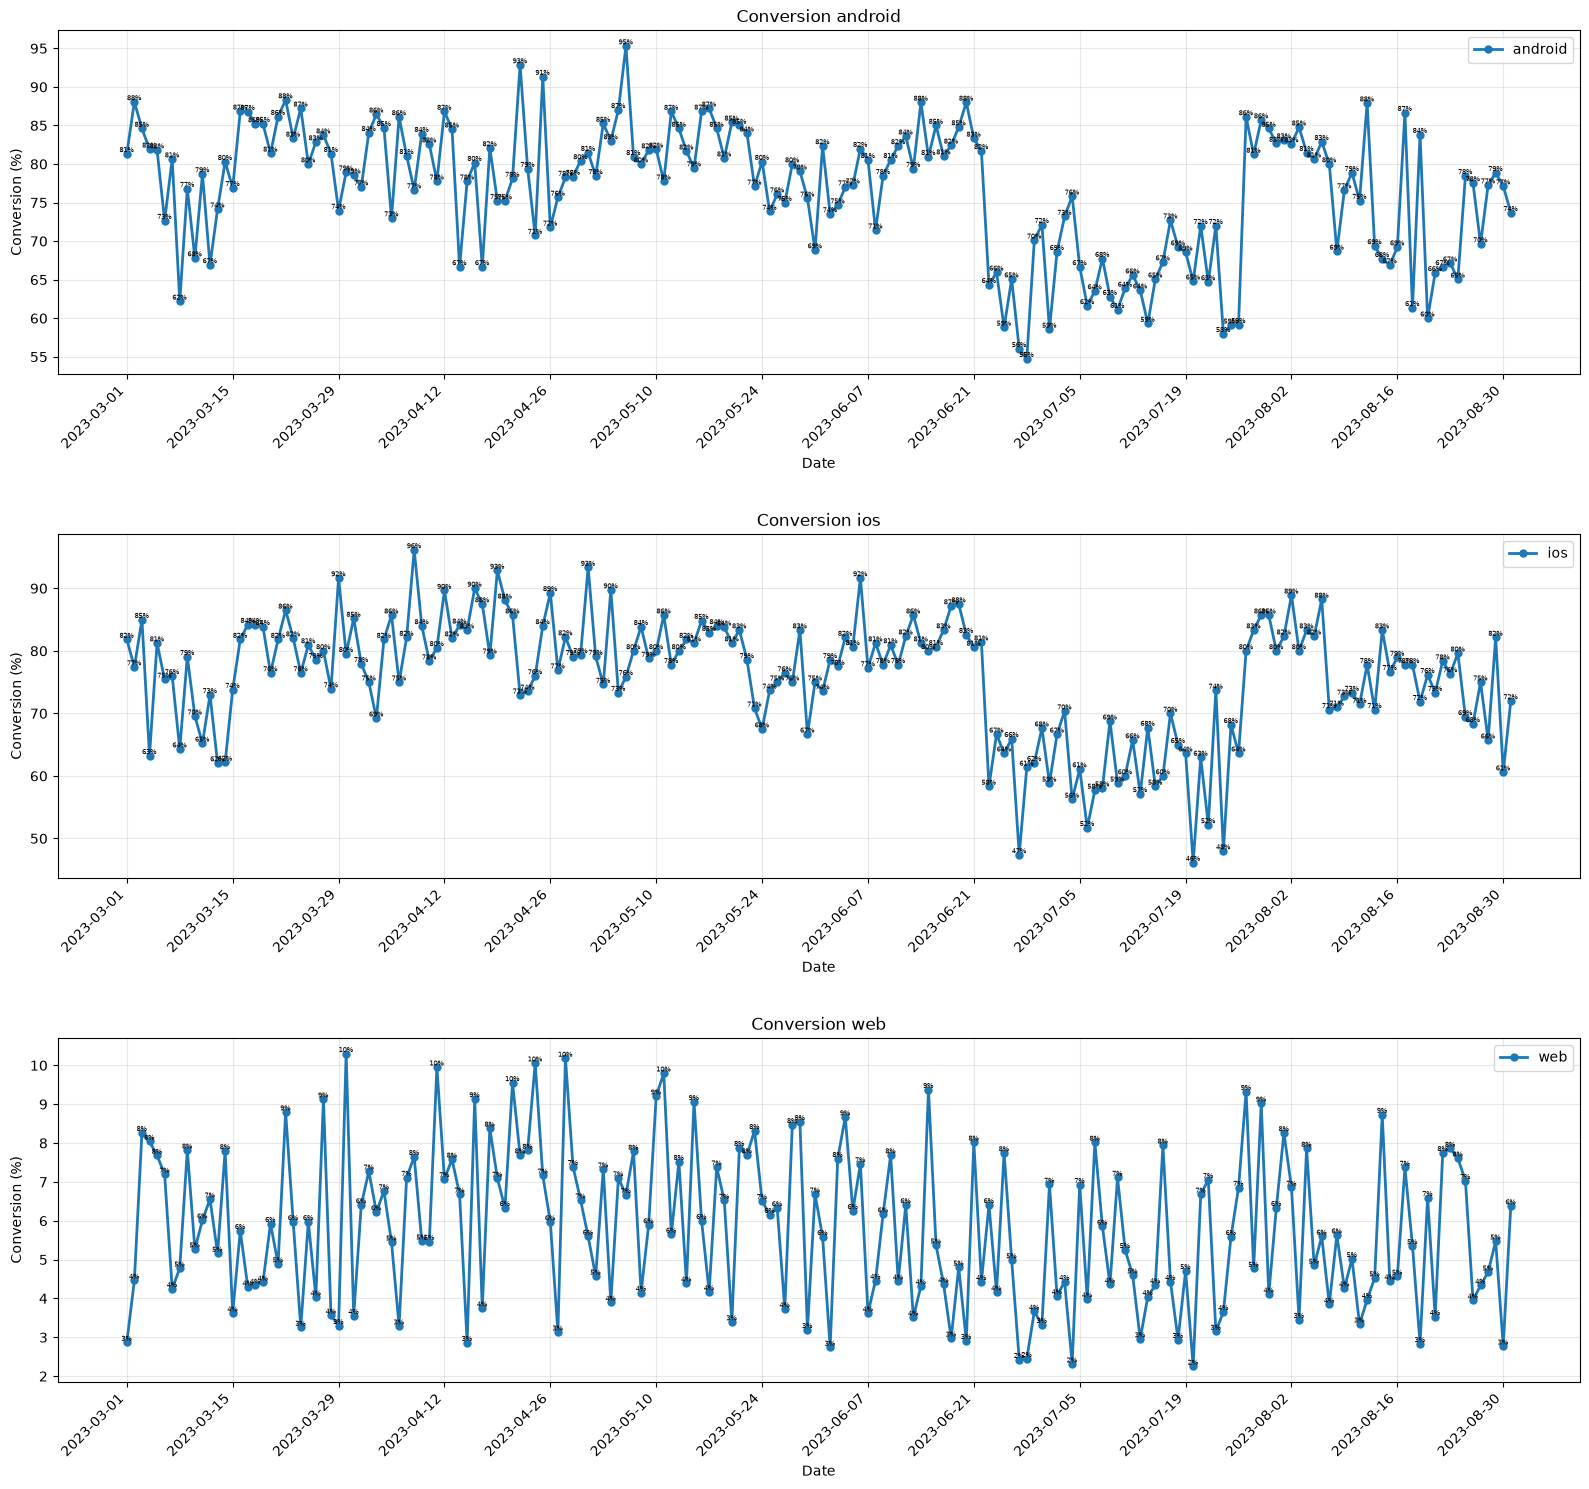

In [64]:
# Конверсия по каждой платформе

platforms = ['android', 'ios', 'web']

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 15)
)

for ax, platform in zip(axes, platforms):
    platform_data = (
        conversion[conversion['platform'] == platform]
        .copy()
        .sort_values('date_group')
    )

    platform_data['date_label'] = (
        platform_data['date_group']
        .dt.strftime('%Y-%m-%d')
    )

    ax.plot(
        platform_data['date_label'],
        platform_data['conversion'],
        marker='o',
        markersize=5,
        linewidth=2,
        label=platform
    )

    ax.set_title(f'Conversion {platform}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Conversion (%)')
    ax.legend()
    ax.grid(alpha=0.3)

    step = 14
    ticks = range(0, len(platform_data), step)

    ax.set_xticks(ticks)
    ax.set_xticklabels(
        platform_data['date_label'].iloc[::step],
        rotation=45,
        ha='right'
    )

    for x, y in zip(
        platform_data['date_label'],
        platform_data['conversion']
    ):
        ax.text(
            x,
            y,
            f'{y:.0f}%',
            ha='center',
            va='bottom',
            fontsize=5
        )

plt.tight_layout(h_pad=3)
plt.savefig('./charts/conversion_by_platform.png')
plt.show()

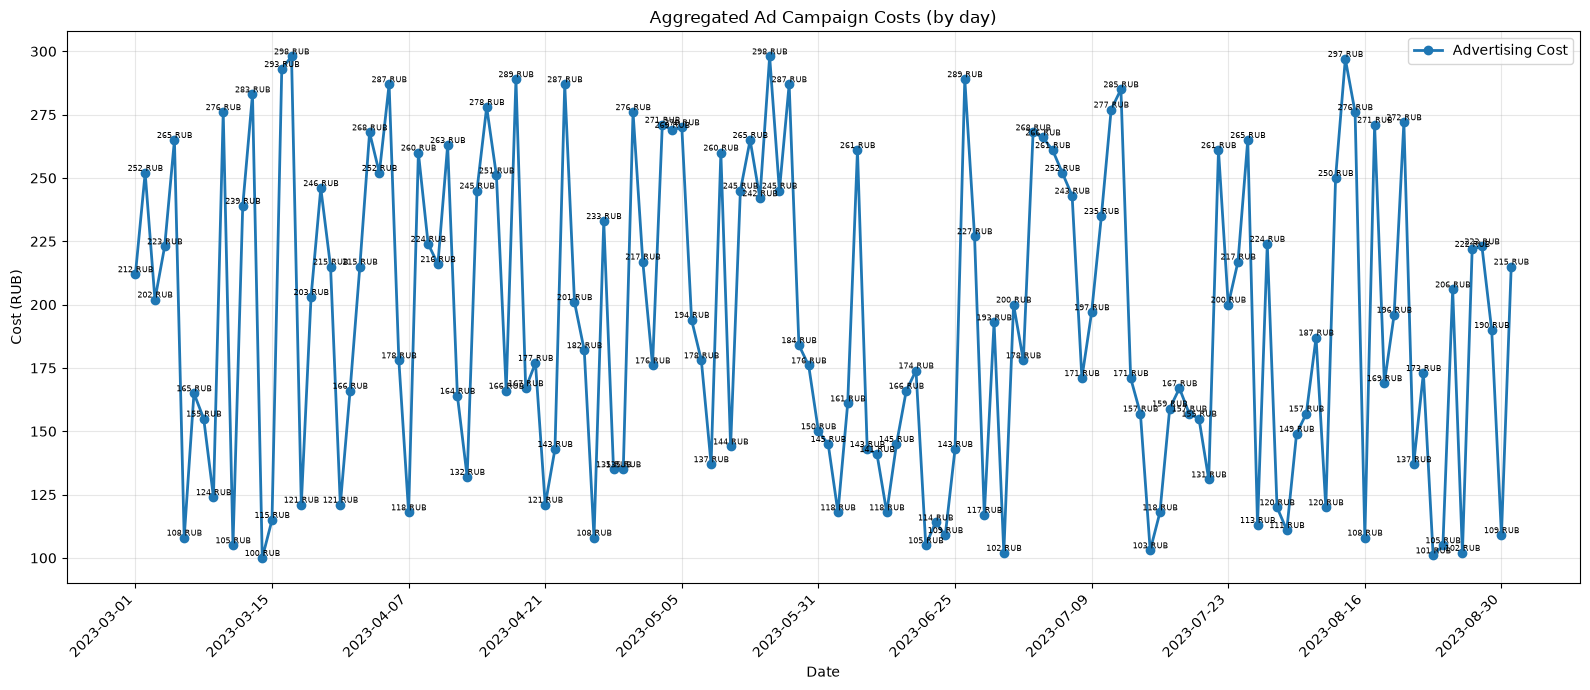

In [65]:
# Общие расходы на рекламу

total_cost = (
    ads_result[ads_result['cost'] > 0]
    .groupby('date_group', as_index=False)['cost']
    .sum()
)

total_cost['date_label'] = (
    total_cost['date_group']
    .dt.strftime('%Y-%m-%d')
)

plt.figure(figsize=(16, 7))

plt.plot(
    total_cost['date_label'],
    total_cost['cost'],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Advertising Cost'
)

plt.title('Aggregated Ad Campaign Costs (by day)')
plt.xlabel('Date')
plt.ylabel('Cost (RUB)')
plt.grid(alpha=0.3)
plt.legend()

ax = plt.gca()

step = 14
ticks = range(0, len(total_cost), step)

ax.set_xticks(ticks)
ax.set_xticklabels(
    total_cost['date_label'].iloc[::step],
    rotation=45,
    ha='right'
)

for x, y in zip(
    total_cost['date_label'],
    total_cost['cost']
):
    ax.text(
        x,
        y,
        f'{int(y)} RUB',
        ha='center',
        va='bottom',
        fontsize=6
    )

plt.tight_layout()
plt.savefig('./charts/advertising_costs.png')
plt.show()

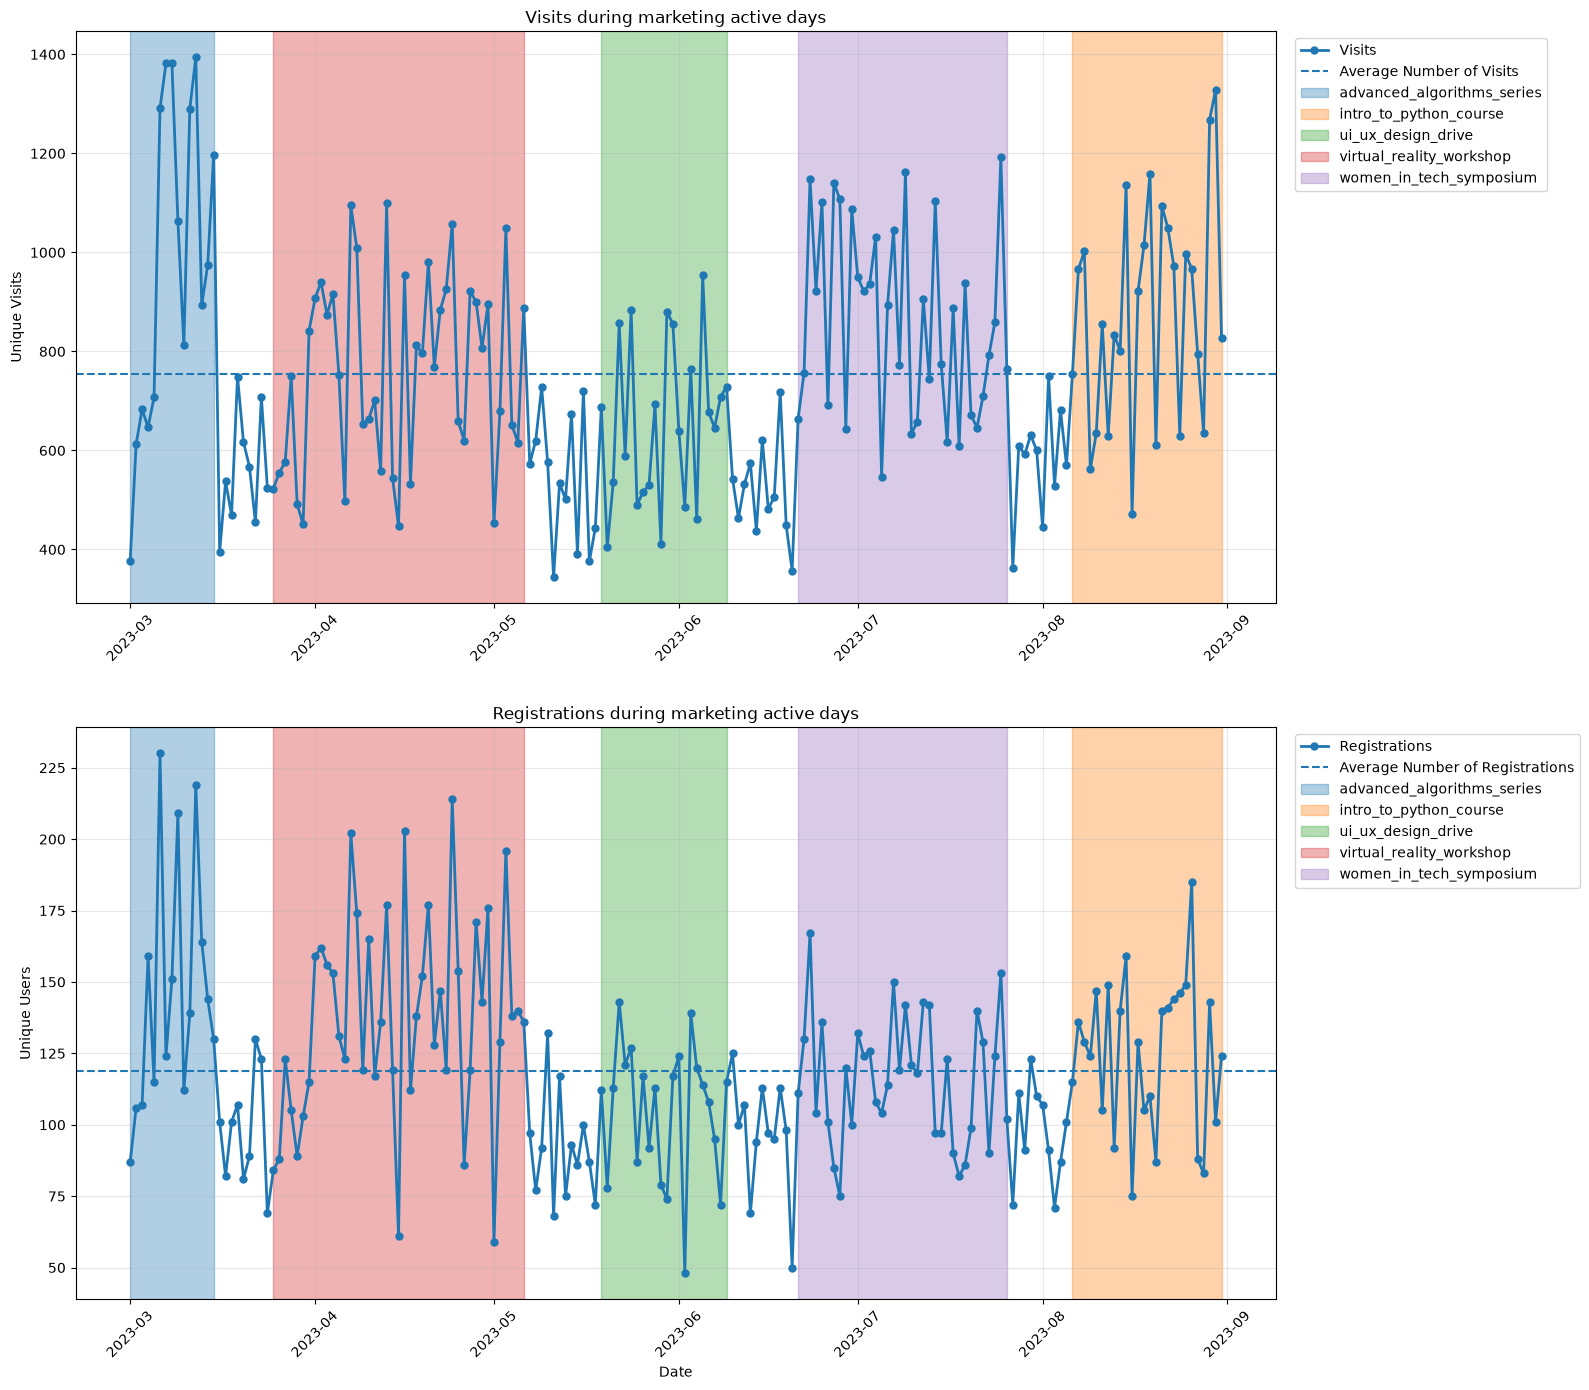

In [66]:
# Визиты и регистрации с выделением рекламных кампаний

marketing_data = (
    ads_result
    .copy()
    .sort_values('date_group')
)

active_campaigns = (
    marketing_data[marketing_data['utm_campaign'] != 'none']
    .groupby('utm_campaign', as_index=False)
    .agg(
        start_date=('date_group', 'min'),
        end_date=('date_group', 'max')
    )
)

campaign_colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown'
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 14)
)

# ---------------------------
# Визиты
# ---------------------------

axes[0].plot(
    marketing_data['date_group'],
    marketing_data['visits'],
    marker='o',
    linewidth=2,
    markersize=5,
    label='Visits'
)

average_visits = marketing_data['visits'].mean()

axes[0].axhline(
    average_visits,
    linestyle='--',
    label='Average Number of Visits'
)

for color, (_, campaign) in zip(
    campaign_colors,
    active_campaigns.iterrows()
):
    axes[0].axvspan(
        campaign['start_date'],
        campaign['end_date'],
        alpha=0.35,
        color=color,
        label=campaign['utm_campaign']
    )

axes[0].set_title('Visits during marketing active days')
axes[0].set_ylabel('Unique Visits')
axes[0].grid(alpha=0.3)

axes[0].legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1)
)

# ---------------------------
# Регистрации
# ---------------------------

axes[1].plot(
    marketing_data['date_group'],
    marketing_data['registrations'],
    marker='o',
    linewidth=2,
    markersize=5,
    label='Registrations'
)

average_registrations = marketing_data['registrations'].mean()

axes[1].axhline(
    average_registrations,
    linestyle='--',
    label='Average Number of Registrations'
)

for color, (_, campaign) in zip(
    campaign_colors,
    active_campaigns.iterrows()
):
    axes[1].axvspan(
        campaign['start_date'],
        campaign['end_date'],
        alpha=0.35,
        color=color,
        label=campaign['utm_campaign']
    )

axes[1].set_title('Registrations during marketing active days')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Unique Users')
axes[1].grid(alpha=0.3)

axes[1].legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1)
)

for ax in axes:
    ax.tick_params(
        axis='x',
        rotation=45
    )

plt.tight_layout(h_pad=3)

plt.savefig(
    './charts/visits_and_registrations_with_campaigns.png',
    bbox_inches='tight'
)

plt.show()

In [67]:
import os

os.listdir('./charts')

['visits_and_registrations_with_campaigns.png',
 'registrations_by_platform.png',
 'total_visits.png',
 'overall_conversion.png',
 'total_registrations.png',
 'advertising_costs.png',
 'visits_by_platform.png',
 'conversion_by_platform.png']